# 05 – Handling Class Imbalance using SMOTE

The dataset shows an imbalanced distribution between censored (alive) and death (event) outcomes.

In this notebook, we:
- Visualize the class imbalance.
- Apply **SMOTE** to generate synthetic samples for the minority class.
- Confirm the new class distribution and save the balanced dataset.


In [2]:
# --- Import libraries ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from google.colab import drive
import os

In [3]:
# --- Mount Google Drive and set paths ---
drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/classification_project'
data_path = f'{base_path}/data'
results_path = f'{base_path}/results'
os.makedirs(results_path, exist_ok=True)

Mounted at /content/drive


In [4]:
# --- Load the encoded dataset from previous step ---
file_path = f'{data_path}/04_encoded_cirrhosis.csv'
df = pd.read_csv(file_path)
print(f" Dataset loaded successfully from: {file_path}")
print("Shape:", df.shape)
display(df.head())

 Dataset loaded successfully from: /content/drive/MyDrive/classification_project/data/04_encoded_cirrhosis.csv
Shape: (418, 19)


,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,400,1,0.0,21464,1,1.0,1.0,1.0,2,2.740840,5.568345,1.280934,5.056246,7.449498,4.934114,5.153292,5.252273,2.580217,4.0
1,4500,0,0.0,20617,1,0.0,1.0,1.0,0,0.741937,5.713733,1.637053,4.007333,8.908668,4.740749,4.488636,5.402677,2.451005,3.0
2,1012,1,0.0,25594,0,0.0,0.0,0.0,1,0.875469,5.176150,1.499623,5.351858,6.248043,4.575741,4.025352,5.023881,2.564949,4.0
3,1925,1,0.0,19994,1,0.0,1.0,1.0,1,1.029619,5.501258,1.264127,4.174387,8.719775,4.121149,4.532599,5.214936,2.424803,4.0
4,1504,0,1.0,13918,1,0.0,1.0,1.0,0,1.481605,5.634790,1.510722,4.969813,6.510258,4.737513,4.290459,4.919981,2.476538,3.0


### Check the current class distribution


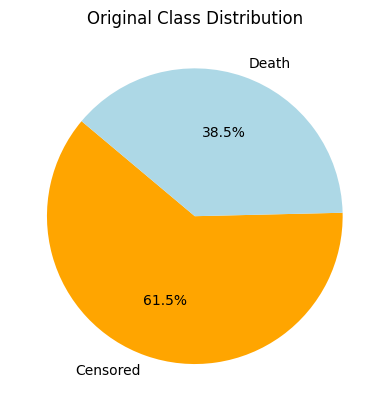

Original class counts:
 Status
0    257
1    161
Name: count, dtype: int64


In [5]:
# --- Check original class imbalance ---
df_counts = df['Status'].value_counts()
df_counts.plot(
    kind='pie',
    labels=["Censored", "Death"],
    colors=['orange', 'lightblue'],
    autopct='%1.1f%%',
    startangle=140
)
plt.title('Original Class Distribution')
plt.ylabel('')
plt.savefig(f'{results_path}/05_original_class_distribution.png', bbox_inches='tight')
plt.show()

print("Original class counts:\n", df_counts)

### Applying SMOTE

We use **SMOTE** to synthetically oversample the minority class (`Death`).


In [6]:
# --- Separate features and target variable ---
X = df.drop('Status', axis=1)
y = df['Status']

# --- Apply SMOTE for balancing ---
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# --- Combine resampled data ---
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['Status'] = y_resampled

print("SMOTE applied successfully.")
print("New class counts:\n", df_resampled['Status'].value_counts())


SMOTE applied successfully.
New class counts:
 Status
1    257
0    257
Name: count, dtype: int64


### Visualize the new class distribution


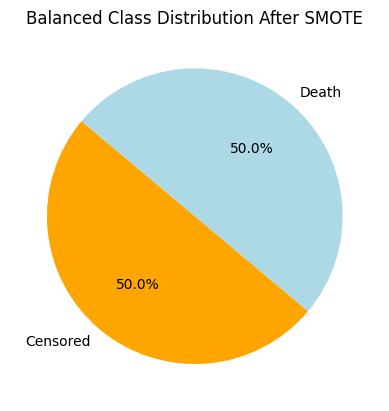

In [7]:
# --- Visualize balanced class distribution ---
df_counts_resampled = df_resampled['Status'].value_counts()
df_counts_resampled.plot(
    kind='pie',
    labels=["Censored", "Death"],
    colors=['orange', 'lightblue'],
    autopct='%1.1f%%',
    startangle=140
)
plt.title('Balanced Class Distribution After SMOTE')
plt.ylabel('')
plt.savefig(f'{results_path}/05_balanced_class_distribution.png', bbox_inches='tight')
plt.show()

In [8]:
# --- Save the balanced dataset for next stage ---
save_path = f'{data_path}/05_balanced_cirrhosis.csv'
df_resampled.to_csv(save_path, index=False)
print(f"Balanced dataset saved to: {save_path}")

Balanced dataset saved to: /content/drive/MyDrive/classification_project/data/05_balanced_cirrhosis.csv


**Next Notebook:** [06_Model_Development_Baseline.ipynb](06_Model_Development_Baseline.ipynb)

We will now build baseline models (Logistic Regression with PCA and Lasso, and Decision Tree)
to establish initial performance benchmarks.
